# Customer Segmentation Analysis

## Objective

Apply clustering algorithms to segment an e-commerce company's customer base into distinct groups based on purchasing behaviour, enabling targeted marketing strategies.

## Dataset

The Online Retail dataset contains transaction-level information about invoices, products, quantities, prices, invoice dates, customer IDs, and countries.

### Importing Required Libraries

The required Python libraries are imported for data manipulation, data visualization, data preprocessing, and K-Means clustering.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

### Loading the Dataset

The Online Retail dataset is loaded into a pandas DataFrame for customer segmentation analysis.

In [24]:
df = pd.read_excel("online_retail_II.xlsx")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


### Inspecting Dataset Structure

The shape, column names, and data types of the dataset are examined to understand its structure.

In [25]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (525461, 8)

Column Names:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[us]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 32.1+ MB


### Checking Missing Values

Missing values are identified in each column before performing data cleaning.

In [26]:
print("Missing Values in Each Column:")
print(df.isnull().sum())

Missing Values in Each Column:
Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64


### Checking Duplicate Records

Duplicate transaction records are identified so that they can be removed during data cleaning.

In [27]:
print("Number of Duplicate Rows:", df.duplicated().sum())

Number of Duplicate Rows: 6865


### Checking Inconsistent Transactions

Negative quantities and zero or negative prices are checked because they may represent returns, cancellations, or invalid transactions.

In [28]:
print("Negative Quantity:", (df['Quantity'] < 0).sum())
print("Zero or Negative Price:", (df['Price'] <= 0).sum())

Negative Quantity: 12326
Zero or Negative Price: 3690


### Observation

The Online Retail dataset contains transaction-level information about customers and their purchases. The dataset was inspected for missing values, duplicate records, and inconsistent transactions. These data quality issues need to be handled before performing customer segmentation.

### Data Cleaning

The dataset is cleaned by removing duplicate records, handling missing Customer IDs, removing invalid transactions, and creating a TotalAmount column for customer purchase analysis.

In [29]:
df = df.rename(columns={'Customer ID': 'CustomerID'})

print(df.columns.tolist())

['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'CustomerID', 'Country']


In [30]:
# Remove duplicate records
df = df.drop_duplicates()

# Remove rows with missing CustomerID
df = df.dropna(subset=['CustomerID'])

# Remove invalid transactions
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]

# Calculate total amount for each transaction
df['TotalAmount'] = df['Quantity'] * df['Price']

print("Cleaned Dataset Shape:", df.shape)

print("\nMissing CustomerID:", df['CustomerID'].isnull().sum())
print("Invalid Quantities:", (df['Quantity'] <= 0).sum())
print("Invalid Prices:", (df['Price'] <= 0).sum())

Cleaned Dataset Shape: (400916, 9)

Missing CustomerID: 0
Invalid Quantities: 0
Invalid Prices: 0


### Verifying the Cleaned Dataset

The cleaned dataset is inspected to confirm that duplicate records, missing customer IDs, and invalid transactions have been handled successfully. The TotalAmount column is also verified.

In [31]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,TotalAmount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


### Observation

Duplicate records, missing Customer IDs, and invalid transactions were removed from the dataset. A TotalAmount feature was created by multiplying Quantity by Price. The cleaned dataset is now ready for customer-level purchasing behaviour analysis.

## 2. Descriptive Statistics

Customer purchasing behaviour is analysed using customer-level metrics such as average purchase value, purchase frequency, and customer lifetime value.

### 2.1 Customer Purchasing Behaviour

The transaction-level data is aggregated for each customer to calculate their purchasing behaviour.

In [32]:
# Calculate customer-level purchasing behaviour

customer_stats = df.groupby('CustomerID').agg(
    Average_Purchase_Value=('TotalAmount', 'mean'),
    Purchase_Frequency=('Invoice', 'nunique'),
    Customer_Lifetime_Value=('TotalAmount', 'sum')
).reset_index()

customer_stats.head()

,CustomerID,Average_Purchase_Value,Purchase_Frequency,Customer_Lifetime_Value
0,12346.0,11.298788,11,372.86
1,12347.0,18.638310,2,1323.32
2,12348.0,11.108000,1,222.16
3,12349.0,26.187647,3,2671.14
4,12351.0,14.330000,1,300.93


### 2.2 Descriptive Statistics

Descriptive statistics are calculated to understand the average purchase value, purchase frequency, and customer lifetime value of the customers.

In [33]:
customer_stats[['Average_Purchase_Value',
                'Purchase_Frequency',
                'Customer_Lifetime_Value']].describe()

,Average_Purchase_Value,Purchase_Frequency,Customer_Lifetime_Value
count,4312.000000,4312.000000,4312.000000
mean,37.009327,4.455705,2040.406712
std,217.715476,8.170213,8911.755977
min,1.993684,1.000000,2.950000
25%,11.193531,1.000000,307.187500
50%,17.361560,2.000000,701.615000
75%,24.839503,5.000000,1714.932500
max,10953.500000,205.000000,349164.350000


### Observation

The descriptive statistics provide an overview of customer purchasing behaviour. The mean values represent the average customer behaviour, while the minimum and maximum values show the range of purchasing activity. These statistics help identify differences in customer spending and purchase frequency.

## 3. Feature Selection — RFM Analysis

RFM analysis is used to identify important customer purchasing behaviour for clustering.

- **Recency:** Number of days since the customer's most recent purchase.
- **Frequency:** Number of unique invoices made by the customer.
- **Monetary:** Total amount spent by the customer.

These three features are selected as the key behavioural features for customer segmentation.

In [34]:
# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Set the reference date as one day after the latest transaction
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Calculate RFM features
rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('TotalAmount', 'sum')
).reset_index()

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,165,11,372.86
1,12347.0,3,2,1323.32
2,12348.0,74,1,222.16
3,12349.0,43,3,2671.14
4,12351.0,11,1,300.93


### 3.2 RFM Descriptive Statistics

Descriptive statistics are calculated for the selected RFM features to understand their range and distribution before clustering.

In [35]:
rfm[['Recency', 'Frequency', 'Monetary']].describe()

,Recency,Frequency,Monetary
count,4312.000000,4312.000000,4312.000000
mean,91.171846,4.455705,2040.406712
std,96.860633,8.170213,8911.755977
min,1.000000,1.000000,2.950000
25%,18.000000,1.000000,307.187500
50%,53.000000,2.000000,701.615000
75%,136.000000,5.000000,1714.932500
max,374.000000,205.000000,349164.350000


### Observation

RFM analysis provides three important behavioural features for customer segmentation. Recency measures how recently customers purchased, Frequency measures how often they purchased, and Monetary measures their total spending. These features will be used for K-Means clustering.

## 4. Data Normalisation / Standardisation

The RFM features have different numerical scales. StandardScaler is used to standardise Recency, Frequency, and Monetary before applying K-Means clustering.

In [36]:
# Select RFM features
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

# Standardise the features
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

# Convert back to DataFrame
rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Frequency', 'Monetary']
)

rfm_scaled_df.head()

,Recency,Frequency,Monetary
0,0.762299,0.801087,-0.187139
1,-0.910402,-0.300603,-0.080475
2,-0.177305,-0.423013,-0.204052
3,-0.497389,-0.178193,0.070784
4,-0.827799,-0.423013,-0.195212


In [37]:
print("Mean of standardised features:")
print(rfm_scaled_df.mean())

print("\nStandard deviation:")
print(rfm_scaled_df.std())

Mean of standardised features:
Recency      5.602610e-17
Frequency    5.932175e-17
Monetary     2.306957e-17
dtype: float64

Standard deviation:
Recency      1.000116
Frequency    1.000116
Monetary     1.000116
dtype: float64


### Observation

The RFM features were standardised using StandardScaler. Standardisation puts the features on a comparable scale, ensuring that no single feature dominates the K-Means clustering process because of its larger numerical values.

## 5. K-Means Clustering

K-Means clustering is applied to divide customers into distinct groups based on their RFM purchasing behaviour.

### 5.1 Elbow Method

The Elbow Method is used to determine the optimal number of clusters. It compares the within-cluster sum of squares (inertia) for different values of K.

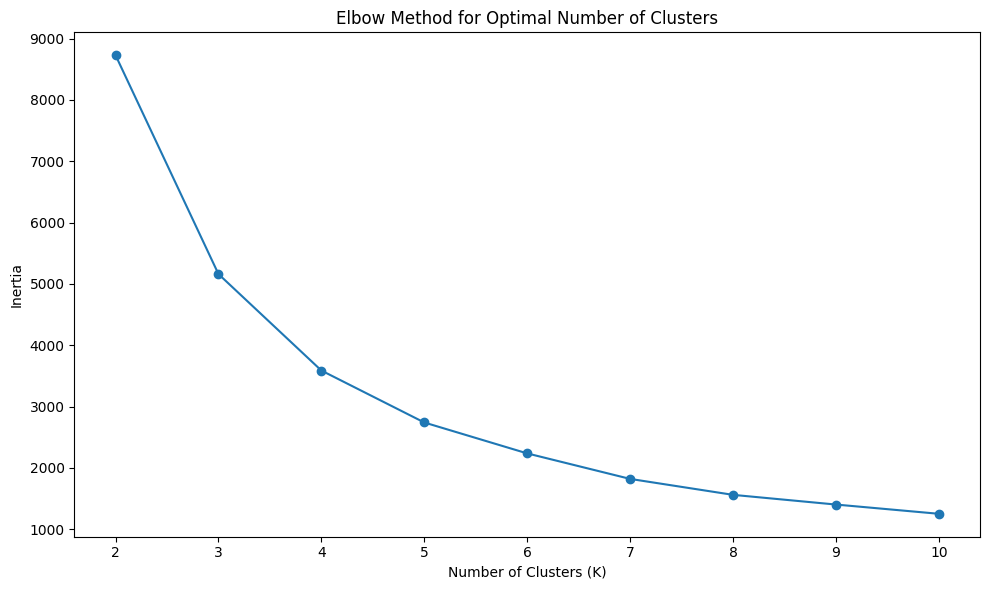

In [38]:
# Calculate inertia for different numbers of clusters

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(range(2, 11))
plt.tight_layout()
plt.show()

### Observation

The Elbow Method was used to evaluate different numbers of clusters. The inertia decreases as the number of clusters increases. The point where the decrease becomes less significant indicates a suitable number of clusters for customer segmentation.

### 5.2 Applying K-Means Clustering

Based on the Elbow Method, four clusters are selected as the optimal number of customer segments. K-Means clustering is applied to the standardised RFM features.

In [39]:
# Apply K-Means with 4 clusters

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Display the first few customers with their cluster
rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,165,11,372.86,1
1,12347.0,3,2,1323.32,0
2,12348.0,74,1,222.16,0
3,12349.0,43,3,2671.14,0
4,12351.0,11,1,300.93,0


### Observation

K-Means clustering divided the customers into four distinct groups based on their Recency, Frequency, and Monetary purchasing behaviour. These clusters represent different types of customers that can be targeted with different marketing strategies.

## 6. Cluster Visualisation

The customer clusters are visualised using scatter plots to understand how the different customer segments are distributed based on their purchasing behaviour.

### 6.1 Recency vs Frequency

The relationship between customer Recency and Frequency is visualised to compare the purchasing behaviour of different customer segments.

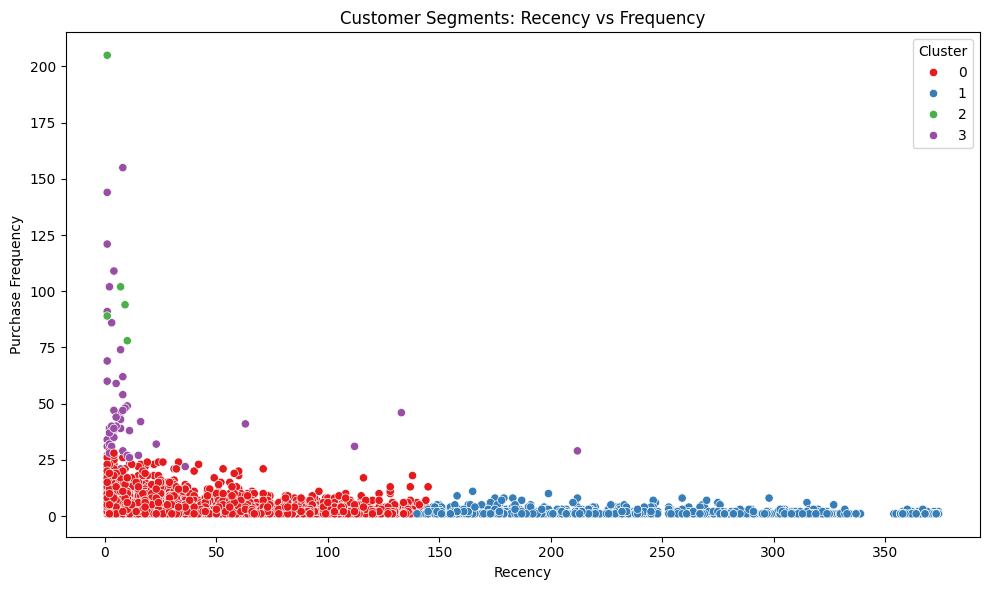

In [40]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Frequency',
    hue='Cluster',
    palette='Set1'
)

plt.title('Customer Segments: Recency vs Frequency')
plt.xlabel('Recency')
plt.ylabel('Purchase Frequency')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

### 6.2 Frequency vs Monetary

The relationship between purchase frequency and total customer spending is visualised to compare the spending behaviour of different customer segments.

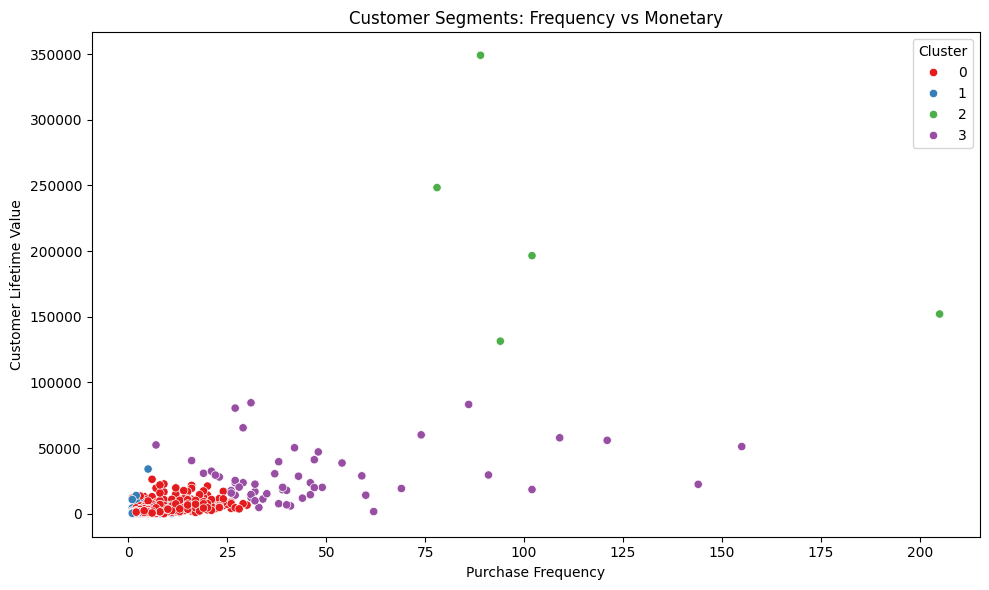

In [41]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='Set1'
)

plt.title('Customer Segments: Frequency vs Monetary')
plt.xlabel('Purchase Frequency')
plt.ylabel('Customer Lifetime Value')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

### Observation

The scatter plots show that customers are divided into four distinct groups based on their purchasing behaviour. The clusters differ in terms of recency, purchase frequency, and monetary value.

## 7. Cluster Profiling

Each customer cluster is profiled by calculating the mean Recency, Frequency, and Monetary values. These values help us understand the purchasing behaviour of each customer segment.

In [42]:
cluster_profile = rfm.groupby('Cluster')[[
    'Recency',
    'Frequency',
    'Monetary'
]].mean().round(2)

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,43.03,4.46,1710.65
1,242.98,1.66,593.54
2,5.60,113.60,215535.00
3,14.91,47.02,28896.42


## 8. Number of Customers per Cluster

The number of customers in each cluster is calculated and visualised using a bar chart. This helps understand the size of each customer segment.

In [43]:
cluster_counts = rfm['Cluster'].value_counts().sort_index()

print("Number of Customers in Each Cluster:")
print(cluster_counts)

Number of Customers in Each Cluster:
Cluster
0    3204
1    1047
2       5
3      56
Name: count, dtype: int64


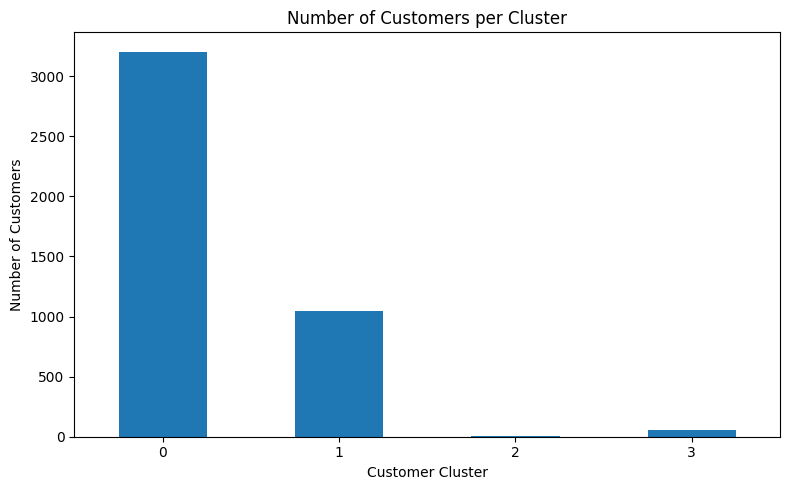

In [44]:
plt.figure(figsize=(8, 5))

cluster_counts.plot(kind='bar')

plt.title('Number of Customers per Cluster')
plt.xlabel('Customer Cluster')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Observation

The bar chart shows the number of customers belonging to each cluster. The size of each customer segment varies, indicating that some customer groups are larger than others.

## 9. Insights and Marketing Recommendations

The customer segments are analysed to identify suitable marketing strategies for each customer group.

### Recommended Marketing Actions

- **Cluster 0 — Regular / Moderate-Value Customers:** Offer personalised discounts, product recommendations, and loyalty rewards to increase purchase frequency and spending.

- **Cluster 1 — At-Risk / Low-Value Customers:** Use re-engagement campaigns, special offers, and reminder emails to encourage customers to return.

- **Cluster 2 — High-Value Loyal Customers:** Provide premium loyalty rewards, exclusive offers, and early access to new products to retain these highly valuable customers.

- **Cluster 3 — High-Value Active Customers:** Encourage repeat purchases through personalised recommendations, loyalty benefits, and cross-selling offers.

### Key Insights

1. The customer base can be divided into four distinct segments based on Recency, Frequency, and Monetary value.

2. Cluster 2 represents the most valuable customer group because it has the highest purchase frequency and monetary value with very low recency.

3. Cluster 1 represents customers with low engagement and should be targeted with re-engagement campaigns.

4. Different customer segments require different marketing strategies rather than a single approach for all customers.

## 10. Conclusion

K-Means clustering and RFM analysis were successfully used to segment e-commerce customers based on their purchasing behaviour. Four distinct customer segments were identified with different levels of recency, purchase frequency, and monetary value.

These customer segments can help businesses design targeted marketing strategies, improve customer retention, and focus resources on high-value customers.